In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
from src.linreg import LinearRegressionprueba
from src.utils import load_data
from src.preprocessing import area_units_conversion

In [11]:
dir_base = "data/processed/"
train_path = dir_base + "casas_train_filled.csv"
validation_path = dir_base + "casas_val_filled.csv"
test_path = dir_base + "casas_test_filled.csv"

def use_test(test_path):
    test = pd.read_csv(test_path)
    test = area_units_conversion(test)
    # test = scale_df(test, train_stats, True)
    return test

test = use_test(test_path)

features = ["area", "is_house", "has_pool", "age", "lat", "lon", "rooms"] 
target = "price"

X_train, y_train = load_data(train_path, None, features, target)
X_val, y_val = load_data(validation_path, None, features, target)
X_test, y_test = load_data("", test, features, target, True)


In [12]:
X_train_1 = X_train[:, [0]]  # Solo area
X_val_1 = X_val[:, [0]]  
X_test_1 = X_test[:, [0]]

modelo = LinearRegressionprueba(X_train_1, y_train, X_val_1, y_val, ["area"])


Error cuadrático medio (RMSE) en test: 84953.1090


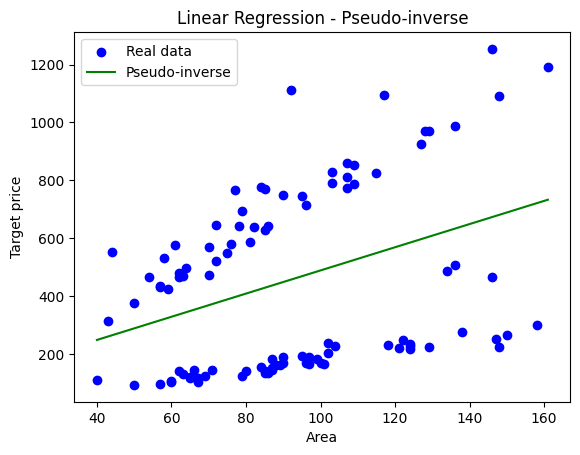

In [13]:
modelo.entrenar_pseudoinversa()
modelo.evaluar(X_test_1, y_test)
modelo.graficar_regresion_pseudoinversa(X_test_1, y_test, ["Area"])


In [ ]:
modelo_pseudo_multi = LinearRegressionprueba(X_train, y_train, X_val, y_val, features)
modelo_pseudo_multi.entrenar_pseudoinversa()
modelo_pseudo_multi.evaluar(X_test, y_test)

TypeError: LinearRegressionprueba.__init__() missing 1 required positional argument: 'feature_names'